전체 데이터 엔트로피: 0.9403
Feature 0의 정보 이득: 0.2467
Feature 1의 정보 이득: 0.0292
Feature 2의 정보 이득: 0.1518
Feature 3의 정보 이득: 0.0481


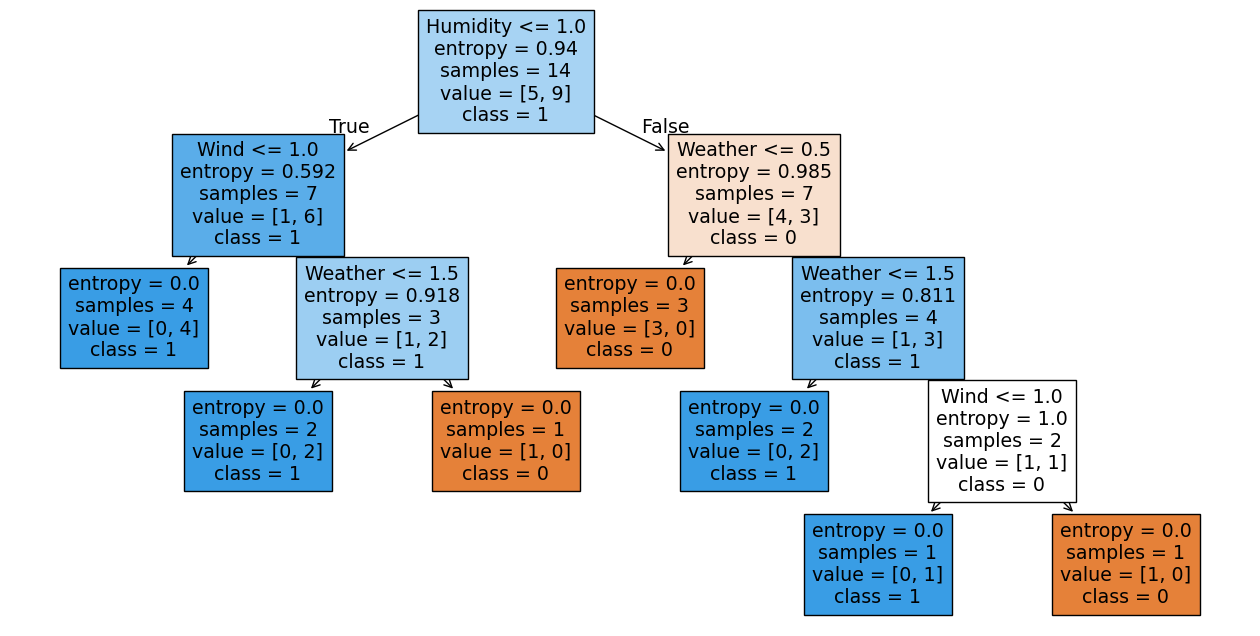

In [ ]:
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image

# Information entropy 함수 정의
def entropy(y):
    # y의 고유값과 각각의 빈도수 계산
    values, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()  # pk
    # 엔트로피 계산
    return -np.sum(p * np.log2(p))

data = np.array([[0, 2, 2, 0, 0],
                [0, 2, 2, 2, 0],
                [1, 2, 2, 0, 1],
                [2, 1, 2, 0, 1],
                [2, 0, 0, 0, 1],
                [2, 0, 0, 2, 0],
                [1, 0, 0, 2, 1],
                [0, 1, 2, 0, 0],
                [0, 0, 0, 0, 1],
                [2, 1, 0, 0, 1],
                [0, 1, 0, 2, 1],
                [1, 1, 2, 2, 1],
                [1, 2, 0, 0, 1],
                [2, 1, 2, 2, 0],])
X = data[:,0:4]
y = data[:,4]

# 전체 데이터의 엔트로피 계산
total_entropy = entropy(y)
print(f"전체 데이터 엔트로피: {total_entropy:.4f}")

#  피처별(기상예보, 온도, 습도, 바람) 정보 이득(Information Gain) 계산
for feature_idx in range(X.shape[1]):
    feature_values = np.unique(X[:, feature_idx])
    feature_entropy = 0
    for value in feature_values:
        # 해당 값에 해당하는 데이터 인덱스
        idx = X[:, feature_idx] == value
        subset_y = y[idx]
        weight = len(subset_y) / len(y)
        subset_entropy = entropy(subset_y)
        feature_entropy += weight * subset_entropy
    info_gain = total_entropy - feature_entropy
    print(f"Feature {feature_idx}의 정보 이득: {info_gain:.4f}")

clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)
clf.fit(X, y)

# Decision Tree for binary classifier
plt.figure(figsize=(16,8))
tree.plot_tree(clf, feature_names=['Weather', 'Temperature', 'Humidity', 'Wind'], class_names=['0', '1'], filled=True)
plt.show()